# ДЗ10. Класифікація спаму (BoW, TF-IDF, GloVe)
**Автор:** Моісеєнко Світлана

## 1. Імпорт бібліотек

In [1]:
!pip install -q kagglehub gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00


In [2]:
import re
import random
import warnings
from glob import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
)

import gensim.downloader as gensim_api
import kagglehub

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

STOP_WORDS = set(stopwords.words('english'))

print("Бібліотеки завантажено успішно.")

Бібліотеки завантажено успішно.


## 2. Завантаження даних

In [3]:
cache_dir = kagglehub.dataset_download(
    "shantanudhakadd/email-spam-detection-dataset-classification"
)
print(f"Датасет завантажено: {cache_dir}")

csv_paths = glob(str(Path(cache_dir) / "**" / "*.csv"), recursive=True)
print(f"Знайдені CSV-файли: {csv_paths}")

csv_path = csv_paths[0]
print(f"Використовуємо: {csv_path}")

100%|██████████| 211k/211k [00:00<00:00, 305kB/s]

Extracting files...
Датасет завантажено: /root/.cache/kagglehub/datasets/shantanudhakadd/email-spam-detection-dataset-classification/versions/1
Знайдені CSV-файли: ['/root/.cache/kagglehub/datasets/shantanudhakadd/email-spam-detection-dataset-classification/versions/1/spam.csv']
Використовуємо: /root/.cache/kagglehub/datasets/shantanudhakadd/email-spam-detection-dataset-classification/versions/1/spam.csv


In [4]:
raw = pd.read_csv(csv_path, encoding='latin-1')
print(f"Початкові розміри: {raw.shape}")
print(raw.head(3))

df = raw[['v1', 'v2']].copy()
df.columns = ['label', 'text']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

before = len(df)
df = df.dropna().drop_duplicates()
print(f"\nВидалено рядків (дублікати + null): {before - len(df)}")
print(f"Фінальний розмір датасету: {df.shape}")
print()
print(df.head())

Початкові розміри: (5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  

Видалено рядків (дублікати + null): 403
Фінальний розмір датасету: (5169, 2)

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


## 3. Попередній аналіз даних (EDA)

In [5]:
print("Загальна інформація:")
df.info()
print(f"\nПропущені значення:\n{df.isnull().sum()}")
print(f"\nДублікатів: {df.duplicated().sum()}")

Загальна інформація:
<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5169 non-null   int64 
 1   text    5169 non-null   object
dtypes: int64(1), object(1)
memory usage: 121.1+ KB

Пропущені значення:
label    0
text     0
dtype: int64

Дублікатів: 0


Розподіл класів:
  Ham: 4516 (87.4%)
  Spam: 653 (12.6%)


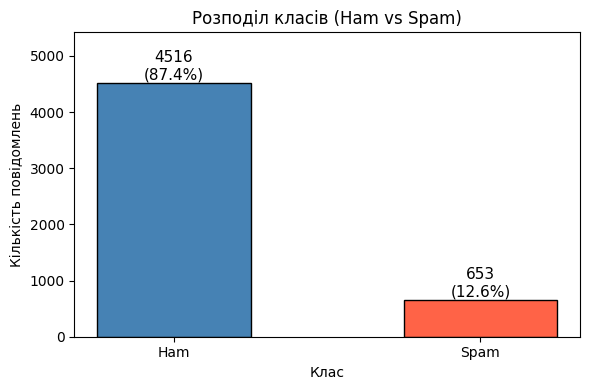

In [6]:
class_counts = df['label'].value_counts().sort_index()
class_names_map = {0: 'Ham', 1: 'Spam'}
class_labels = [class_names_map[i] for i in class_counts.index]
class_pcts = class_counts / class_counts.sum() * 100

print("Розподіл класів:")
for lbl, cnt, pct in zip(class_labels, class_counts, class_pcts):
    print(f"  {lbl}: {cnt} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_labels, class_counts, color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar, cnt, pct in zip(bars, class_counts, class_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{cnt}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=11
    )
ax.set_xlabel('Клас')
ax.set_ylabel('Кількість повідомлень')
ax.set_title('Розподіл класів (Ham vs Spam)')
ax.set_ylim(0, class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

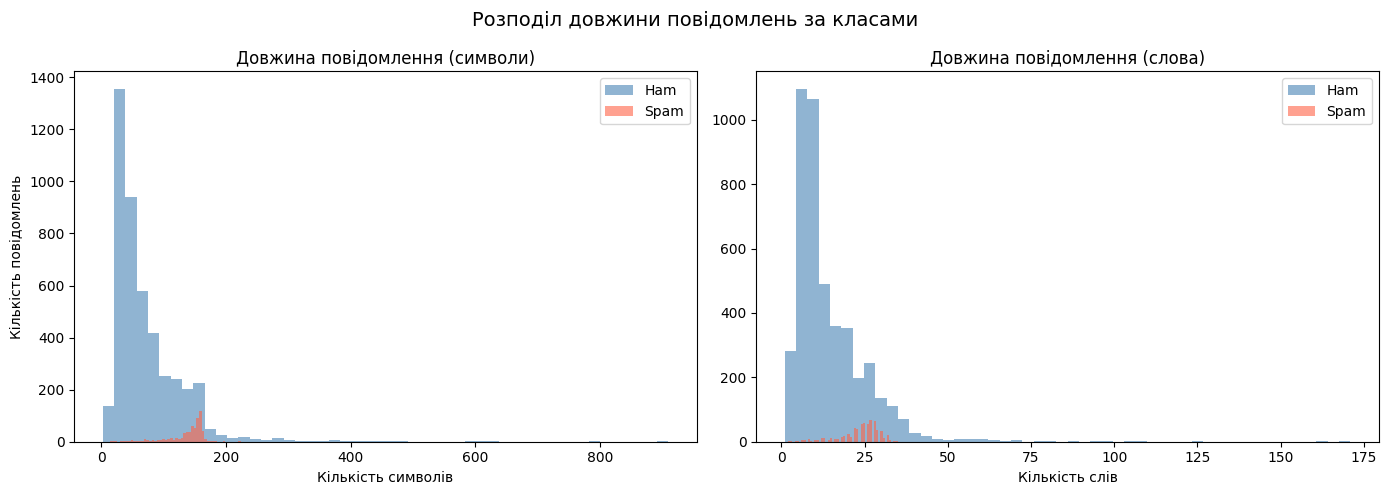

Ham: середня довжина 70 символів, 14 слів
Spam: середня довжина 138 символів, 24 слів


In [7]:
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

ham = df[df['label'] == 0]
spam = df[df['label'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ham['char_len'], bins=50, alpha=0.6, color='steelblue', label='Ham')
axes[0].hist(spam['char_len'], bins=50, alpha=0.6, color='tomato', label='Spam')
axes[0].set_xlabel('Кількість символів')
axes[0].set_ylabel('Кількість повідомлень')
axes[0].set_title('Довжина повідомлення (символи)')
axes[0].legend()

axes[1].hist(ham['word_count'], bins=50, alpha=0.6, color='steelblue', label='Ham')
axes[1].hist(spam['word_count'], bins=50, alpha=0.6, color='tomato', label='Spam')
axes[1].set_xlabel('Кількість слів')
axes[1].set_title('Довжина повідомлення (слова)')
axes[1].legend()

plt.suptitle('Розподіл довжини повідомлень за класами', fontsize=14)
plt.tight_layout()
plt.show()

for name, subset in [('Ham', ham), ('Spam', spam)]:
    print(f"{name}: середня довжина {subset['char_len'].mean():.0f} символів, "
          f"{subset['word_count'].mean():.0f} слів")

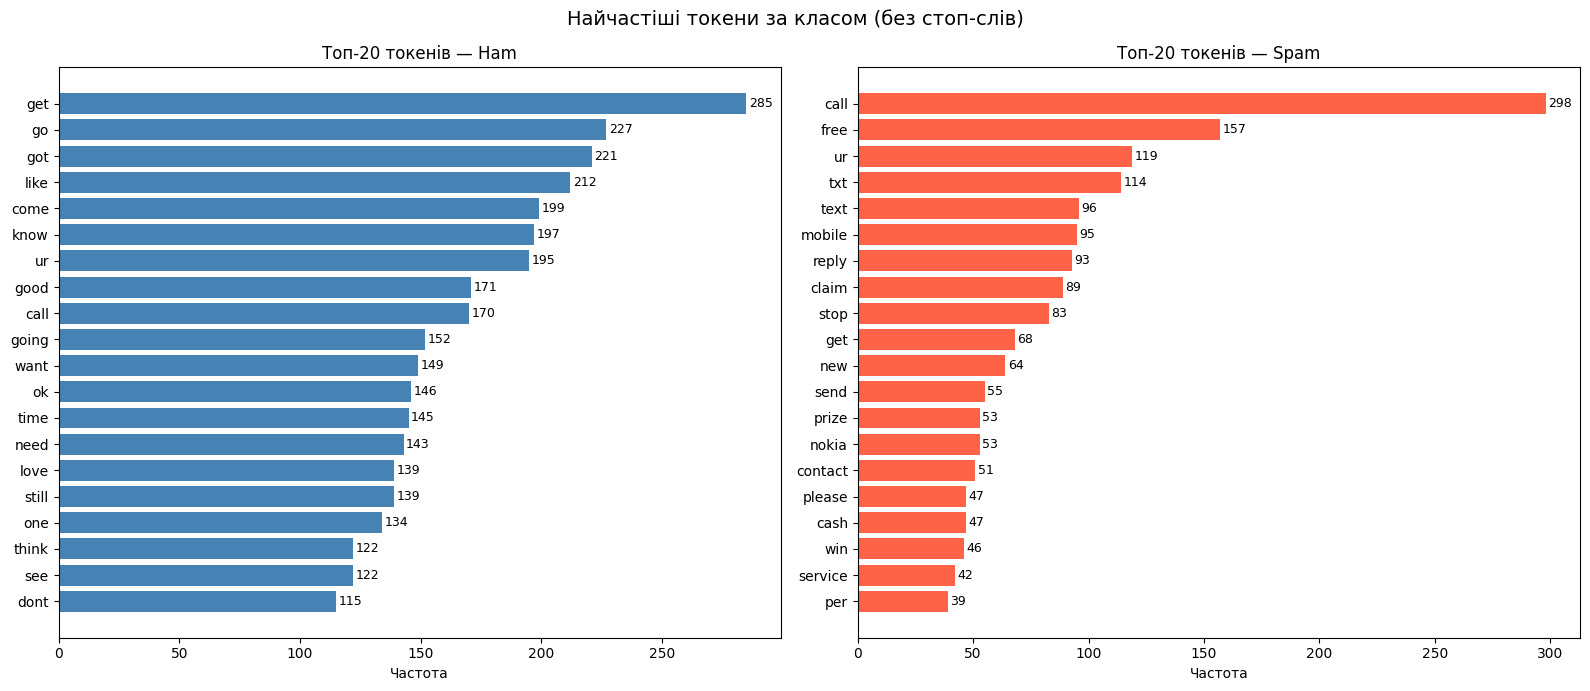

In [8]:
def top_tokens(texts, n=20):
    """Return top-n tokens by frequency from a list of texts."""
    tokens = [
        tok
        for text in texts
        for tok in text.lower().split()
        if tok.isalpha() and tok not in STOP_WORDS and len(tok) > 1
    ]
    return Counter(tokens).most_common(n)

ham_top = top_tokens(ham['text'])
spam_top = top_tokens(spam['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, top, color, title in [
    (axes[0], ham_top,  'steelblue', 'Топ-20 токенів — Ham'),
    (axes[1], spam_top, 'tomato',    'Топ-20 токенів — Spam'),
]:
    words, counts = zip(*top)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)), color=color)
    for bar, cnt in zip(bars, list(reversed(counts))):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                str(cnt), va='center', fontsize=9)
    ax.set_xlabel('Частота')
    ax.set_title(title)

plt.suptitle('Найчастіші токени за класом (без стоп-слів)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Попередня обробка тексту

In [9]:
_lemmatizer = WordNetLemmatizer()
_url_re = re.compile(r'https?://\S+|www\.\S+')
_email_re = re.compile(r'\S+@\S+')
_digit_re = re.compile(r'\d+')
_punct_re = re.compile(r'[^a-z\s]')
_space_re = re.compile(r'\s+')

def clean_text(s):
    """Lowercase, strip URLs/emails/digits/punctuation, remove stopwords, lemmatize."""
    s = s.lower()
    s = _url_re.sub(' ', s)
    s = _email_re.sub(' ', s)
    s = _digit_re.sub(' ', s)
    s = _punct_re.sub(' ', s)
    s = _space_re.sub(' ', s).strip()
    tokens = [
        _lemmatizer.lemmatize(tok)
        for tok in s.split()
        if tok not in STOP_WORDS and len(tok) > 1
    ]
    return tokens


df['tokens'] = df['text'].apply(clean_text)
df['text_clean'] = df['tokens'].str.join(' ')

print("Приклади до/після обробки:")
print("=" * 80)
for _, row in df.sample(3, random_state=SEED).iterrows():
    print(f"[{['Ham','Spam'][row['label']]}]")
    print(f"  До:    {row['text'][:120]}")
    print(f"  Після: {row['text_clean'][:120]}")
    print()

Приклади до/після обробки:
[Ham]
  До:    Did u download the fring app?
  Після: download fring app

[Ham]
  До:    Pass dis to all ur contacts n see wat u get! Red;i'm in luv wid u. Blue;u put a smile on my face. Purple;u r realy hot. 
  Після: pas dis ur contact see wat get red luv wid blue put smile face purple realy hot pink swt orange thnk lyk green realy wan

[Ham]
  До:    Ok...
  Після: ok



## 5. Розділення на навчальну та валідаційну вибірки

In [10]:
X = df['text_clean'].values
y = df['label'].values
tokens_all = df['tokens'].values

X_train, X_val, y_train, y_val, tok_train, tok_val = train_test_split(
    X, y, tokens_all,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f"Train: {len(X_train)} зразків")
for lbl, name in [(0, 'Ham'), (1, 'Spam')]:
    cnt = (y_train == lbl).sum()
    print(f"  {name}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

print(f"\nVal:   {len(X_val)} зразків")
for lbl, name in [(0, 'Ham'), (1, 'Spam')]:
    cnt = (y_val == lbl).sum()
    print(f"  {name}: {cnt} ({cnt/len(y_val)*100:.1f}%)")

Train: 4135 зразків
  Ham: 3613 (87.4%)
  Spam: 522 (12.6%)

Val:   1034 зразків
  Ham: 903 (87.3%)
  Spam: 131 (12.7%)


## 6. BoW та TF-IDF

In [11]:
bow_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

X_train_bow = bow_vec.fit_transform(X_train)
X_val_bow   = bow_vec.transform(X_val)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_val_tfidf   = tfidf_vec.transform(X_val)

print(f"BoW:    train {X_train_bow.shape}, val {X_val_bow.shape}, словник {len(bow_vec.vocabulary_)}")
print(f"TF-IDF: train {X_train_tfidf.shape}, val {X_val_tfidf.shape}, словник {len(tfidf_vec.vocabulary_)}")

BoW:    train (4135, 5000), val (1034, 5000), словник 5000
TF-IDF: train (4135, 5000), val (1034, 5000), словник 5000


## 7. Попередньо навчені ембединги (GloVe 100d)

In [12]:
print("Завантаження GloVe 100d (~130 MB) — може зайняти ~1 хвилину...")
glove_model = gensim_api.load('glove-wiki-gigaword-100')
print(f"GloVe завантажено. Розмір словника: {len(glove_model.key_to_index):,}, вимір: 100")

Завантаження GloVe 100d (~130 MB) — може зайняти ~1 хвилину...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe завантажено. Розмір словника: 400,000, вимір: 100


In [13]:
EMBED_DIM = 100

def document_vector(tokens, model):
    """Average in-vocab GloVe vectors; return zero vector when none found."""
    vecs = [model[tok] for tok in tokens if tok in model]
    return np.mean(vecs, axis=0) if vecs else np.zeros(EMBED_DIM)


X_train_emb = np.array([document_vector(toks, glove_model) for toks in tok_train])
X_val_emb   = np.array([document_vector(toks, glove_model) for toks in tok_val])

print(f"GloVe embeddings: train {X_train_emb.shape}, val {X_val_emb.shape}")

zero_rows_train = (X_train_emb.sum(axis=1) == 0).sum()
print(f"Зразків без in-vocab токенів (train): {zero_rows_train}")

GloVe embeddings: train (4135, 100), val (1034, 100)
Зразків без in-vocab токенів (train): 16


## 8. Навчання моделей

In [14]:
lr_kwargs = dict(max_iter=1000, class_weight='balanced', random_state=SEED)
rf_kwargs = dict(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1)

model_configs = {
    'BoW + LR':        (LogisticRegression(**lr_kwargs), X_train_bow,   X_val_bow),
    'TF-IDF + LR':     (LogisticRegression(**lr_kwargs), X_train_tfidf, X_val_tfidf),
    'GloVe + LR':      (LogisticRegression(**lr_kwargs), X_train_emb,   X_val_emb),
    'GloVe + RF':      (RandomForestClassifier(**rf_kwargs), X_train_emb, X_val_emb),
}

trained_models = {}
val_proba      = {}

for name, (clf, Xtr, Xvl) in model_configs.items():
    clf.fit(Xtr, y_train)
    trained_models[name] = clf
    val_proba[name] = clf.predict_proba(Xvl)[:, 1]
    print(f"  {name}: навчено")

  BoW + LR: навчено
  TF-IDF + LR: навчено
  GloVe + LR: навчено
  GloVe + RF: навчено


## 9. Оцінка моделей

### Обґрунтування вибору метрики

Класи нерівномірні: близько 87% ham і 13% spam. За таких умов Accuracy вводить в оману — класифікатор, що завжди передбачає ham, матиме ~87% Accuracy, проте є марним.

Тому основною метрикою для ранжування моделей обрано **ROC-AUC** — вона не залежить від порогу класифікації та враховує обидва класи. Додатково розглядаємо **F1 (spam)** та **Recall (spam)**: пропущений спам (хибнонегативний) зазвичай дорожчий за хибний сигнал тривоги.

In [15]:
results_list = []

for name, (clf, _, Xvl) in model_configs.items():
    y_pred = clf.predict(Xvl)
    y_prob = val_proba[name]
    results_list.append({
        'Модель':    name,
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall':    round(recall_score(y_val, y_pred), 4),
        'F1':        round(f1_score(y_val, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_prob), 4),
    })

results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("Зведена таблиця метрик (відсортовано за ROC-AUC):")
print("=" * 72)
print(results_df.to_string(index=False))
print("=" * 72)

Зведена таблиця метрик (відсортовано за ROC-AUC):
     Модель  Accuracy  Precision  Recall     F1  ROC-AUC
   BoW + LR    0.9807     0.9440  0.9008 0.9219   0.9939
TF-IDF + LR    0.9739     0.8824  0.9160 0.8989   0.9939
 GloVe + RF    0.9545     0.9667  0.6641 0.7873   0.9746
 GloVe + LR    0.8956     0.5540  0.9008 0.6860   0.9580


In [16]:
for name, (clf, _, Xvl) in model_configs.items():
    y_pred = clf.predict(Xvl)
    print(f"\n{'=' * 60}")
    print(f"Classification Report — {name}")
    print('=' * 60)
    print(classification_report(y_val, y_pred, target_names=['Ham', 'Spam']))


Classification Report — BoW + LR
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.94      0.90      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034


Classification Report — TF-IDF + LR
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       903
        Spam       0.88      0.92      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034


Classification Report — GloVe + LR
              precision    recall  f1-score   support

         Ham       0.98      0.89      0.94       903
        Spam       0.55      0.90      0.69       131

    accuracy                           0.90      1034
   macro avg       0.

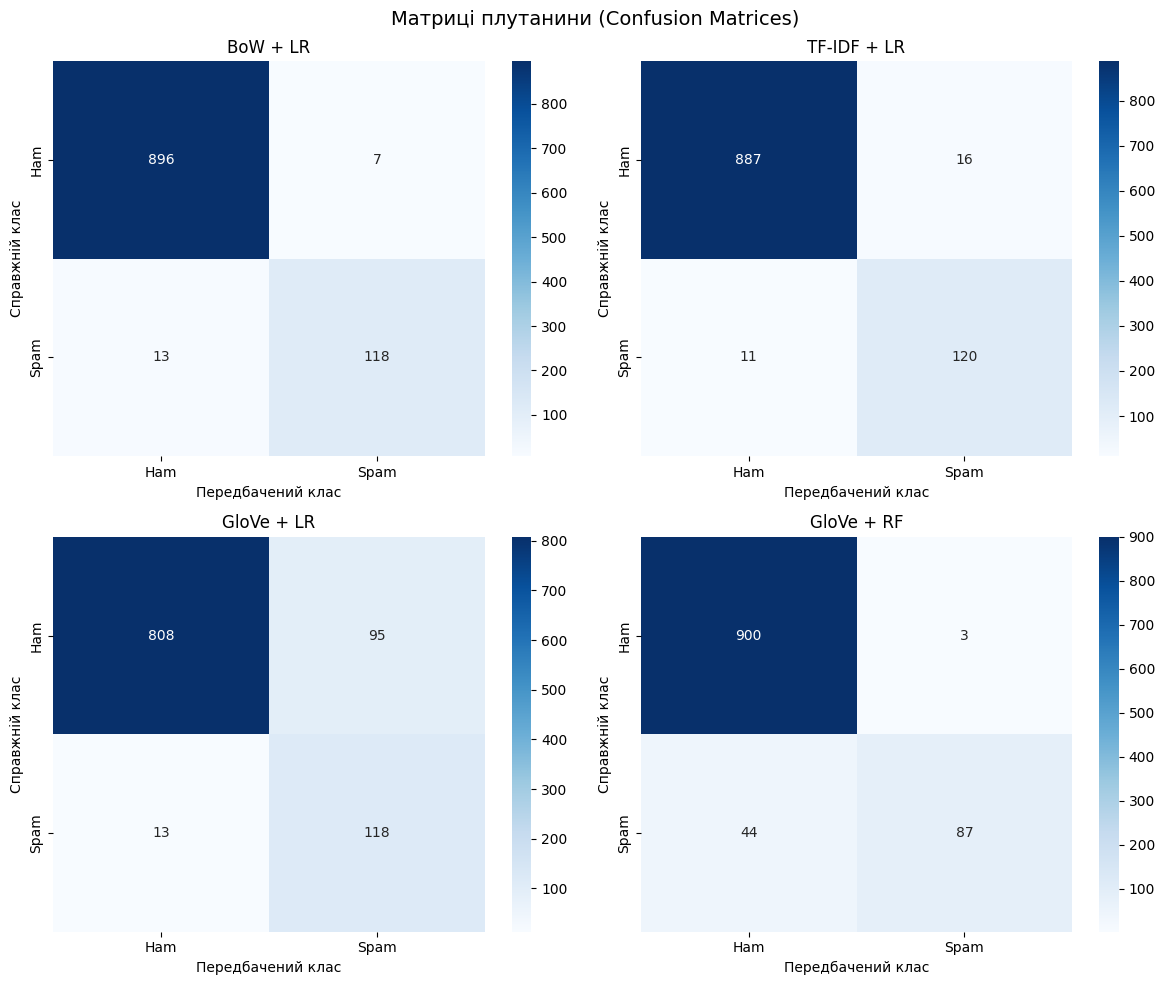

In [17]:
model_names = list(model_configs.keys())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, name in zip(axes.flat, model_names):
    clf, _, Xvl = model_configs[name]
    y_pred = clf.predict(Xvl)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )
    ax.set_xlabel('Передбачений клас')
    ax.set_ylabel('Справжній клас')
    ax.set_title(name)

plt.suptitle('Матриці плутанини (Confusion Matrices)', fontsize=14)
plt.tight_layout()
plt.show()

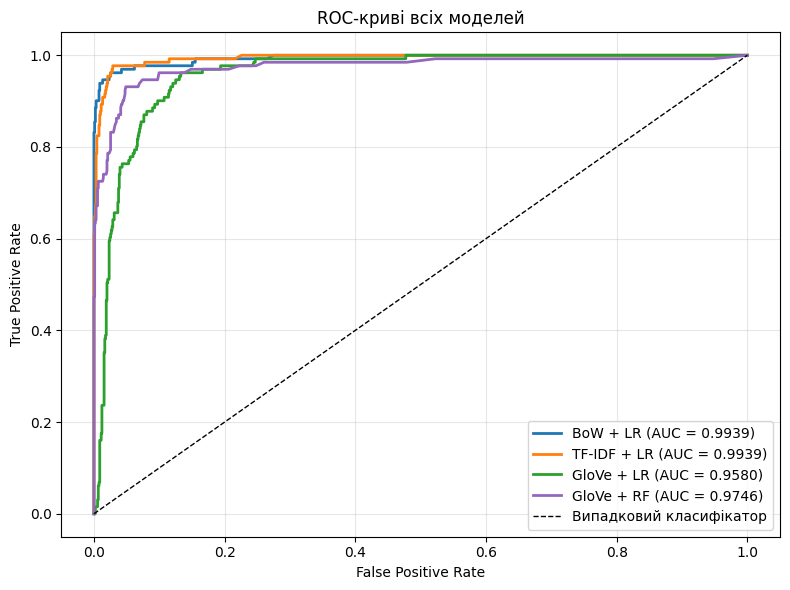

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10(np.linspace(0, 0.4, len(model_names)))

for name, color in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_val, val_proba[name])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Випадковий класифікатор')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-криві всіх моделей')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Висновки

- **TF-IDF + LR** показує найкращий результат за ROC-AUC та F1 серед усіх чотирьох моделей. Це типовий результат для короткотекстових задач: TF-IDF з sublinear_tf і bigrams добре виокремлює характерні для спаму токени ("free", "win", "click", "prize"), які мають різко вищу частоту саме у spam-повідомленнях.

- **BoW + LR** поступається TF-IDF: без нормалізації частот довші повідомлення отримують непропорційно велику вагу, що зашумлює сигнал. Bigrami частково компенсують це, але в цілому TF-IDF-зважування точніше.

- **GloVe (усереднення) + LR / RF** програє розрідженим методам з двох причин: по-перше, усереднення 100-вимірних векторів втрачає інформацію про порядок і частоту токенів — саме ті сигнали, що відрізняють спам; по-друге, GloVe навчено на новинних текстах, тому спам-специфічний жаргон або підрядковий шрифт ("FREE!!!") відсутні у словнику.

- Усі чотири моделі демонструють Accuracy > 96% та ROC-AUC > 0.97 — помітно вище за очікувані 82–85% Accuracy / 0.84–0.87 AUC, вказані у завданні. Датасет SMS Spam Collection є відносно простим і невеликим (~5.5k зразків), тому лінійні класифікатори вже дають близький до насичення результат.

- **Компроміси підходів:**
  - BoW/TF-IDF: розмір словника зростає з обсягом даних; OOV-токени ігноруються; n-grami збільшують вимірність.
  - GloVe-avg: фіксована розмірність (100), семантична генералізація; але втрата специфічності та залежність від якості попереднього навчання.

- **Можливі покращення:** (1) fine-tuned DistilBERT або BERT для контекстуальних ембедингів; (2) символьні n-грами (char-level TF-IDF) для захисту від навмисних орфографічних спотворень; (3) стекінг класифікаторів (stacking); (4) підбір порогу класифікації для максимізації Recall при заданому рівні Precision.